In [1]:
#core
import numpy as np
import pandas as pd

#preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("train (1).csv")
test = pd.read_csv("test (1).csv")

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (1460, 81)
test shape: (1459, 80)


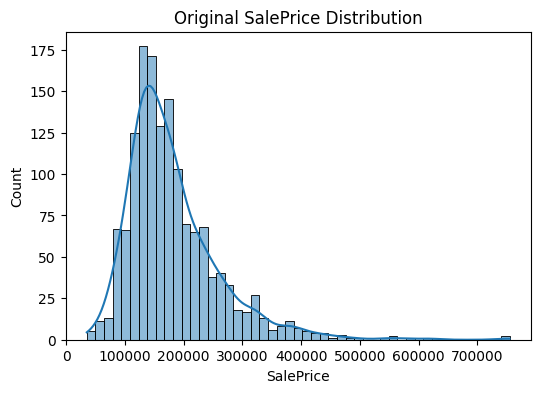

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Original SalePrice Distribution")
plt.show()

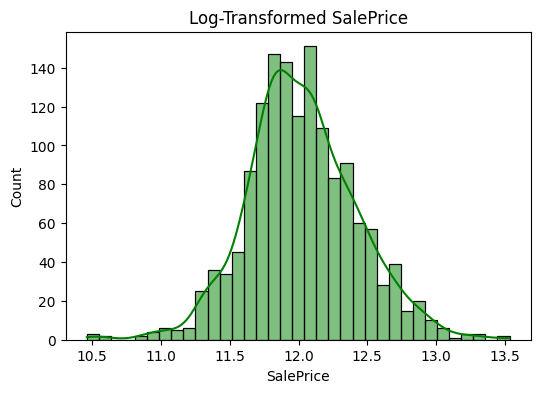

In [5]:
y = np.log1p(train["SalePrice"])

plt.figure(figsize=(6,4))
sns.histplot(y, kde=True, color="green")
plt.title("Log-Transformed SalePrice")
plt.show()

In [6]:
features = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "OverallQual",
    "YearBuilt"
]

target = "SalePrice"

df = train[features + [target]]

In [7]:
df.loc[:, "SalePrice_log"] = np.log1p(df.loc[:, "SalePrice"])

C:\Users\Pranjal\AppData\Local\Temp\ipykernel_14136\2968116381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "SalePrice_log"] = np.log1p(df.loc[:, "SalePrice"])


In [8]:
X = df[features]
y = df["SalePrice_log"]

In [9]:
#train-validaton split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#baseline linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_log = lr.predict(X_val)
pred = np.expm1(pred_log)
actual = np.expm1(y_val)

rmse = np.sqrt(mean_squared_error(actual, pred))
rmse

np.float64(35520.81977989043)

In [11]:
#optimization
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None


In [12]:
cv_rmse = -cross_val_score(
    ridge_pipeline,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse.mean()

np.float64(0.18682272089421825)

In [13]:
ridge_pipeline.fit(X, y)

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None


In [14]:
X_test = test[features]
X_test = X_test.fillna(X_test.median())

test_pred_log = ridge_pipeline.predict(X_test)
test_pred = np.expm1(test_pred_log)

In [15]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

,Id,SalePrice
0,1461,117528.038128
1,1462,149030.412926
2,1463,163676.971401
3,1464,184494.584809
4,1465,211836.854258
